In [247]:
import pandas as pd
import numpy as np


df = pd.read_csv('enhanced_student_habits_performance_dataset.csv')
df.head()

,student_id,age,gender,major,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,attendance_percentage,sleep_hours,...,screen_time,study_environment,access_to_tutoring,family_income_range,parental_support_level,motivation_level,exam_anxiety_score,learning_style,time_management_score,exam_score
0,100000,26,Male,Computer Science,7.645367,3.0,0.1,Yes,70.3,6.2,...,10.9,Co-Learning Group,Yes,High,9,7,8,Reading,3.0,100
1,100001,28,Male,Arts,5.700000,0.5,0.4,No,88.4,7.2,...,8.3,Co-Learning Group,Yes,Low,7,2,10,Reading,6.0,99
2,100002,17,Male,Arts,2.400000,4.2,0.7,No,82.1,9.2,...,8.0,Library,Yes,High,3,9,6,Kinesthetic,7.6,98
3,100003,27,Other,Psychology,3.400000,4.6,2.3,Yes,79.3,4.2,...,11.7,Co-Learning Group,Yes,Low,5,3,10,Reading,3.2,100
4,100004,25,Female,Business,4.700000,0.8,2.7,Yes,62.9,6.5,...,9.4,Quiet Room,Yes,Medium,9,1,10,Reading,7.1,98


In [248]:
df.shape

(80000, 31)

In [249]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [250]:
df.info()

df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 80000 entries, 0 to 79999
Data columns (total 31 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   student_id                     80000 non-null  int64  
 1   age                            80000 non-null  int64  
 2   gender                         80000 non-null  object 
 3   major                          80000 non-null  object 
 4   study_hours_per_day            80000 non-null  float64
 5   social_media_hours             80000 non-null  float64
 6   netflix_hours                  80000 non-null  float64
 7   part_time_job                  80000 non-null  object 
 8   attendance_percentage          80000 non-null  float64
 9   sleep_hours                    80000 non-null  float64
 10  diet_quality                   80000 non-null  object 
 11  exercise_frequency             80000 non-null  int64  
 12  parental_education_level       80000 non-null 

,0
student_id,0
age,0
gender,0
major,0
study_hours_per_day,0
social_media_hours,0
netflix_hours,0
part_time_job,0
attendance_percentage,0
sleep_hours,0


In [251]:
# Remove unnecessary columns
df = df.drop(columns=['student_id','index', 'attendance_percentage','exercise_frequency','diet_quality','parental_education_level','internet_quality','mental_health_rating','extracurricular_participation','exam_score'], errors='ignore')
df.head()

,age,gender,major,study_hours_per_day,social_media_hours,netflix_hours,part_time_job,sleep_hours,previous_gpa,semester,...,social_activity,screen_time,study_environment,access_to_tutoring,family_income_range,parental_support_level,motivation_level,exam_anxiety_score,learning_style,time_management_score
0,26,Male,Computer Science,7.645367,3.0,0.1,Yes,6.2,4.00,5,...,0,10.9,Co-Learning Group,Yes,High,9,7,8,Reading,3.0
1,28,Male,Arts,5.700000,0.5,0.4,No,7.2,4.00,7,...,5,8.3,Co-Learning Group,Yes,Low,7,2,10,Reading,6.0
2,17,Male,Arts,2.400000,4.2,0.7,No,9.2,3.79,4,...,5,8.0,Library,Yes,High,3,9,6,Kinesthetic,7.6
3,27,Other,Psychology,3.400000,4.6,2.3,Yes,4.2,4.00,6,...,3,11.7,Co-Learning Group,Yes,Low,5,3,10,Reading,3.2
4,25,Female,Business,4.700000,0.8,2.7,Yes,6.5,4.00,4,...,2,9.4,Quiet Room,Yes,Medium,9,1,10,Reading,7.1


In [252]:
df.describe()

,age,study_hours_per_day,social_media_hours,netflix_hours,sleep_hours,previous_gpa,semester,stress_level,social_activity,screen_time,parental_support_level,motivation_level,exam_anxiety_score,time_management_score
count,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000,80000.000000
mean,22.004288,4.174388,2.501366,1.997754,7.017417,3.602448,4.497338,5.012478,2.500225,9.673029,5.479438,5.488525,8.508475,5.499132
std,3.745570,2.004135,1.445441,1.155992,1.467377,0.462876,2.295312,1.953174,1.704292,2.780869,2.873327,2.867782,1.796411,2.603534
min,16.000000,0.000000,0.000000,0.000000,4.000000,1.640000,1.000000,1.000000,0.000000,0.300000,1.000000,1.000000,5.000000,1.000000
25%,19.000000,2.800000,1.200000,1.000000,6.000000,3.270000,2.000000,3.600000,1.000000,7.800000,3.000000,3.000000,7.000000,3.200000
50%,22.000000,4.125624,2.500000,2.000000,7.000000,3.790000,5.000000,5.000000,2.000000,9.700000,5.000000,5.000000,10.000000,5.500000
75%,25.000000,5.500000,3.800000,3.000000,8.000000,4.000000,7.000000,6.400000,4.000000,11.600000,8.000000,8.000000,10.000000,7.800000
max,28.000000,12.000000,5.000000,4.000000,12.000000,4.000000,8.000000,10.000000,5.000000,21.000000,10.000000,10.000000,10.000000,10.000000


In [253]:
#removing duplicates
df = df.drop_duplicates()


In [254]:
#remove rows where sleep_hours is too high or too low
Q1 = df['sleep_hours'].quantile(0.25)
Q3 = df['sleep_hours'].quantile(0.75)
IQR = Q3 - Q1
df = df[~((df['sleep_hours'] < (Q1 - 1.5 * IQR)) | (df['sleep_hours'] > (Q3 + 1.5 * IQR)))]


In [255]:
# Remove rows where study_hours_per_day is too high or too low
Q1 = df['study_hours_per_day'].quantile(0.25)
Q3 = df['study_hours_per_day'].quantile(0.75)
IQR = Q3 - Q1

df = df[~((df['study_hours_per_day'] < (Q1 - 1.5 * IQR)) |
          (df['study_hours_per_day'] > (Q3 + 1.5 * IQR)))]

In [256]:
df.shape

(79370, 22)

In [257]:
#extract total social media hours per day
df['total_social_hours'] = df['netflix_hours'] + df['social_media_hours']

In [258]:
df['focus_ratio'] = df['study_hours_per_day'] / (
    df['study_hours_per_day'] + df['total_social_hours'] + 1
)

In [259]:
threshold = 0.5

df['task_completed'] = (
    df['focus_ratio'] +
    np.random.normal(0, 0.1, len(df))  # human inconsistency
    > threshold
).astype(int)

In [260]:
df['task_completed'].value_counts()


,count
task_completed,
0,52393
1,26977


In [261]:
features = [
    'age',
    'gender',
    'part_time_job',
    'study_hours_per_day',
    'sleep_hours',
    'total_social_hours'
]

X = df[features]
y = df['task_completed']

In [262]:
X = pd.get_dummies(X, columns=['gender', 'part_time_job'], drop_first=True)

In [263]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [264]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_bal, y_train_bal = smote.fit_resample(X_train, y_train)

In [265]:
print("y_train before SMOTE:")
print(y_train.value_counts())

print("\ny_test:")
print(y_test.value_counts())

print("\ny_train after SMOTE:")
print(y_train_bal.value_counts())

y_train before SMOTE:
task_completed
0    41914
1    21582
Name: count, dtype: int64

y_test:
task_completed
0    10479
1     5395
Name: count, dtype: int64

y_train after SMOTE:
task_completed
1    41914
0    41914
Name: count, dtype: int64


In [266]:
from sklearn.preprocessing import StandardScaler

num_cols = [
    'age',
    'study_hours_per_day',
    'sleep_hours',
    'total_social_hours'
]

scaler = StandardScaler()
X_train_bal[num_cols] = scaler.fit_transform(X_train_bal[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

In [267]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier(
    max_depth=5,
    min_samples_split=20,
    min_samples_leaf=10,
    random_state=42
)

model.fit(X_train_bal, y_train_bal)

DecisionTreeClassifier(max_depth=5, min_samples_leaf=10, min_samples_split=20,
                       random_state=42)

In [268]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

y_pred = model.predict(X_test)

print("Accuracy:", round(accuracy_score(y_test, y_pred), 3))
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


Accuracy: 0.805

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.80      0.84     10479
           1       0.67      0.82      0.74      5395

    accuracy                           0.81     15874
   macro avg       0.79      0.81      0.79     15874
weighted avg       0.82      0.81      0.81     15874



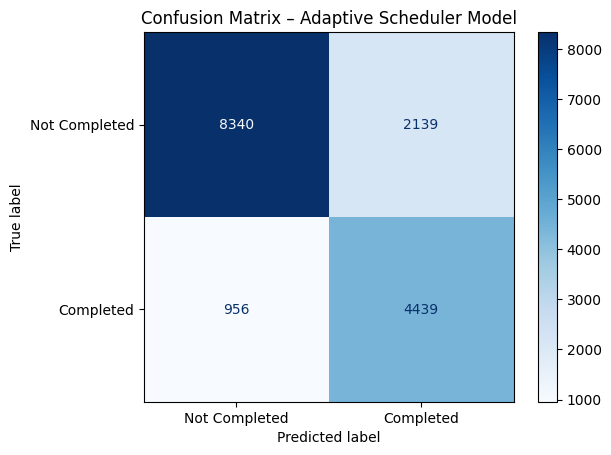

In [269]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt



# Generate confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Display confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm,
                              display_labels=['Not Completed', 'Completed'])

disp.plot(cmap='Blues')
plt.title("Confusion Matrix – Adaptive Scheduler Model")
plt.show()